## Formatting for Plots
### (IGNORE THIS IF YOU ARE A GENERAL USER)

In [ ]:
# Set import path for custom libraries
import sys
from pathlib import Path
root = Path().resolve()
src_path = root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from analysislib import formatting
from analysislib import graphs

formatting.format_notebook() # Format the notebook

---

## Part 1 — Introduction

---

<br>

<div style="width: 1200px">
<center>
<span style="
border: 2px solid #DDDDDD;
padding: 15px;
font-size: 20px;
font-style: italic;">
"What drives galaxy transformation, and can we predict where a galaxy is in its evolutionary lifecycle?"</span>
</center>

<br>

This is the central question guiding this entire project. To answer it, we need real data, and lots of it. In this introduction section, we will meet the dataset that is used for the data analysis in this project: the **Sloan Digital Sky Survey (SDSS)**.

However, before we touch a single number, we'll need build up a clear picture of what the SDSS is, how its data was collected, and what each column in the dataset actually represents physically.

By the end of this notebook, you will:

* Understand how the SDSS telescope captures data about the sky
* Know what a spectrograph does and why redshift matters
* Be able to distinguish between stars, galaxies, and quasars
* Have taken a first look at the dataset's shape, contents, and quality
* Have cleaned the data so it is ready for analysis in later chapters

<br>

<center><img width=500px src="images/hst_galaxies.jpg"></img>

<i>Credit: ESA/Hubble & NASA, F. Pacaud, D. Coe</i></center>
</div>

---

### Assumed Background Knowledge and Important Details

---

<div style="width: 1200px">

This project is aimed at a general audience, but a little background high-school knowledge will help. Specifically, you should be comfortable with:

* The idea that light behaves like a wave with a **wavelength**, and that wavelength determines colour
* A basic understanding of solids, liquids and gasses, and the idea that the universe is made up of different types of elements, like hydrogen, oxygen and iron
* Basic astronomical terms like "star" and "galaxy"
* General scientific / maths vocabulary like: "telescope", "graph", "machine learning", "mean", "median" and "mode"

Everything else will be introduced and explained along the way :)

<br>

Also, there will be several instances where I use Python code to do some analysis. I have tried to explain the code as much as possible in the greyed-out comments, and I would encourage you to have a look at the code, even if you don't do coding. However, feel free to skip over it and just read the explanations and look at the graphs if you would rather just see the results of the analysis.

* *Note that for the purposes of this being a resource for the general public, some of the code used is packaged into a custom library called "analysislib". If you are a developer or wish to see the full code, please navigate to "src/analysislib" on my GitHub (https://github.com/haylamyuen/Project-GATORS)*

</div>

---

### The Sloan Digital Sky Survey

---

<div style="
display: inline-block;
width: 650px;
margin-right: 100px">

The **Sloan Digital Sky Survey (SDSS)** is one of the most ambitious astronomical projects ever undertaken. Since it began in 2000, a dedicated telescope in New Mexico has been systematically photographing and measuring large portions of the night sky, producing a publicly available dataset that's now the foundation of thousands of scientific studies worldwide.

The thing that makes the SDSS so powerful is that it uses both **photometry** and **spectroscopy**, which together give us both a broad overview of the sky and a deeper understanding of the individual objects.

For this project, we use the first 500,000 entries of the SDSS-V Data Release 19 (July 2025). This sample gives us enough objects to find some statistical patterns in galaxy properties, which will ultimately let us figure out where galaxies are in their evolutionary lifecycle.

</div>

<div style="
display: inline-block;
width: 400px;">
<img src="images/sdss_telescope.jpg"></img>
<center><i>Credit: Patrick Gaulme</i></center>
</div>

---

### How the SDSS Telescope Sees the Sky

---

The SDSS collects data in two very different ways:

#### Photometry

<div style="width: 1200px">

**Photometry** is the process of measuring how bright an object appears across different wavelengths of light.

Rather than taking a single image, the SDSS observes each object through five filters labelled `u`, `g`, `r`, `i`, and `z`, which cover a range from ultraviolet to infrared. Each filter captures only a small part of the spectrum, and the combination of all five tells us the object's overall **colour profile**.

Colour turns out to be deeply informative:

* **Blue galaxies** tend to be hot and actively forming new stars
* **Red galaxies** are usually older, cooler, or have stopped forming stars

<br>

<center>
<div style="width: 800px">
<img src="images/em_spectrum.png"></img>
</div>
</center>

<center><i>Credit: Haylam Yuen</i></center>
</div>

#### Spectroscopy

<div style="
display: inline-block;
width: 450px;
margin-right: 25px">

While photometry gives us colour and shape, **spectroscopy** tells us more complex details about the objects.

A **spectrograph** works by taking the incoming light from a celestial object and fanning it out into a full spectrum. But unlike a rainbow, this spectrum contains sharp **absorption and emission lines** at very specific wavelengths.

Interestingly, every chemical element interacts with light at its own unique set of wavelengths, a bit like a fingerprint. By identifying which lines appear in a spectrum, astronomers can determine **exactly which elements are present** in the object.

Spectroscopy can therefore tell us:

* The **chemical composition** of the object (hydrogen, helium, heavier metals)
* The **type** of object and its **age**
* And crucially, its **redshift**, which tells us how far away it is (more on this below)

</div>

<div style="
display: inline-block;
width: 700px;">
<img src="images/spectra_emission.png"></img>

<center><i>Credit: NASA</i></center>
</div>

---

### The Idea of Redshift

---

<div style="width: 1200px">

<center>
<img src="images/redshift_diagram.jpg" width=550px></img>

<i>Credit: Bartleby</i>
</center>

<br>

One of the most important quantities in this dataset is **redshift**. To understand it intuitively, imagine light as a series of waves rippling outward from a distant object. As the universe expands, space itself is being stretched, and as it stretches, so do the light waves travelling through it.

Because of this, light from distant objects arrives at Earth with a longer wavelength than it had when it was emitted. Since longer wavelengths sit toward the red end of the visible spectrum, we call this **redshift**. Conversely, objects moving toward us have their light compressed to shorter (bluer) wavelengths. This is called **blueshift**, although this is rare on cosmological scales.

Redshift is powerful for two main reasons:

1. It lets us figure out **Distance**: A higher redshift generally means the object is farther away.

2. It tells us about the **Universe's past**: Because light travels at a finite speed (~300,000 km/s), observing a galaxy with high redshift means that we get to look into the past. For example, if a galaxy has $z = 0.5$, we are seeing it as it was about 5 billion years ago (which is awesome!)

<br>

The interactive plot below lets you simulate how redshift shifts the colour of objects. The H-alpha emission line (the bright red line hydrogen emits at 656 nm) is a real reference used by astronomers to measure galaxy distances:

</div>

In [ ]:
graphs.interactive_redshift() # Display the interactive redshift plot

---

### The Three Types of Objects in the SDSS

---

<div style="width: 1200px">

Every object in the SDSS is assigned to one of three categories:

<br>

**STARS**

Stars are individual suns just like our own. In the SDSS dataset, all detected stars belong to our own galaxy, the Milky Way, making them relatively nearby on cosmic scales. They appear as **point sources** with no visible structure. Stars are not the main subject of this project, but they appear in the data and can be used as calibration references.

<br>

**GALAXIES**

Galaxies are the main stuff we're focused on in this project. Each one is an enormous thing containing anywhere from millions to trillions of stars, plus big clouds of gas, dust, and invisible dark matter. Unlike stars, galaxies can appear **extended**, meaning they have visible shape and structure. They evolve dramatically over cosmic time: merging, quenching their star formation, changing colour and morphology. Tracing this evolution is the main aim of the project.

<br>

**QUASI-STELLAR OBJECTS / QUASARS (QSOs)**

Quasars are some of the brightest objects in the known universe. They are powered by **supermassive black holes** at the centres of galaxies, which are actively consuming surrounding matter and releasing masssive amounts of energy in the process. This energy can outshine the entire host galaxy, making quasars appear **point-like** (similar to stars). However, like stars, they won't really be used in this project.

</div>

---

### Bias and Limitations of the SDSS

---

<div style="width: 1200px">
No dataset is perfect, so addressing the SDSS's known limitations is important for doing the best analysis possible.

* **Flux limit (Malmquist bias):** The telescope can only detect objects above a minimum brightness. This means faint, distant galaxies are systematically underrepresented and the sample is biased toward intrinsically bright or nearby objects.

* **Spectroscopic target selection:** Not every photometrically detected object gets a spectroscopic reading. The SDSS prioritised certain object types for this, so the dataset might over-represent large red galaxies and quasars relative to fainter, "normal" objects.

* **Sky coverage:** The SDSS primarily surveys the Northern Galactic Cap, leaving large portions of the sky unmapped. Large-scale structural studies may therefore be incomplete.

* **Fibre collision:** The physical spectrograph uses optical fibres to capture light. These fibres cannot be placed closer than about 55 arcseconds apart (1 60th of a degree), meaning that dense environments like galaxy clusters may be undersampled.

* **Sample ordering:** The first 500,000 entries of the database may not be a truly random draw from the sky. Database ordering (by sky region or observation date) could introduce hidden structure in the sample.

It's important that we keep these caveats in mind throughout the analysis.
</div>

---

### First Look at the Data

---

Now that we've addressed some of the important background information of the SDSS, it's time to load the dataset and begin exploring its structure. We'll use a Python extension called **Pandas**:

In [ ]:
import pandas as pd # Import the pandas library for data manipulation

df = pd.read_csv("data/SDSS_500k_v7.csv") # Load the SDSS dataset from a CSV file into a DataFrame (kind of like a table)
print(f"Dataset loaded: {len(df):,} objects, {df.shape[1]} columns") # Print the number of objects (rows) and columns in the dataset

Awesome! Let's inspect the first few rows. Each row is one celestial object, and each column is a measured property of that object.

In [ ]:
df.head() # Display the first few rows of the dataset to get an idea of its structure and contents

And just for good measure, let's generate a statistical summary of all numerical columns. Don't worry if you don't know what some of the stuff means.

In [ ]:
df.describe() # Get summary statistics of the dataset to understand the distribution of values in each column

#### What Do the Columns Mean?

<div style="width: 1200px;">

Here is a general guide to every column in our dataset, and what they actually mean:

| Column | Physical meaning |
|--------|------------------|
| `objID` | Unique identifier from photometric data (We can use this to look up any object in the SDSS online database) |
| `ra`, `dec` | **Right Ascension** and **Declination** are essentially the longitude and latitude of the sky. Together they give an object's precise position on the celestial sphere |
| `u`, `g`, `r`, `i`, `z` | Brightness in the five photometric bands: ultraviolet, green, red, near-infrared, and mid-infrared. Differences between these values encode the object's **colour** |
| `class` | Object type: `GALAXY`, `STAR`, or `QSO` |
| `redshift` | The measured redshift ($z$) |
| `zWarning` | A number* which flags certain issues when the data was processed. `0` means no problems. Non-zero values indicate the redshift measurement may be unreliable |
| `petroRad_r` | **Petrosian radius** in the r-band, which measures apparent galaxy size |
| `petroMag_r` | **Petrosian magnitude** in the r-band, which measures total brightness within the Petrosian radius |
| `petro_R50_r`, `petro_R90_r` | The radii which 50% and 90% of the galaxy's brightness are contained respectively |
| `expAB_r`, `deVAB_r` | Axis ratios from the two profile fits (essentially how round vs. elongated the object appears) |

<br>

\* Technically it is a **bitmask**, but for our purposes, you can just think of it as a number

<br>

<center>
<img width=350px src="images/ra_dec.jpg"></img>
<img width=525px src="images/petrosian_r.jpg"></img>

<i><b>LEFT</b>: Right Ascension and Declination. Credit: Bob King, <b>RIGHT</b>: The Petrosian radius. Credit: Michael Richmond</i>
</center>

</div>

---

### The Data that we are Dealing With

---

Next, let's get a feel for the raw dataset through two little visualisations:

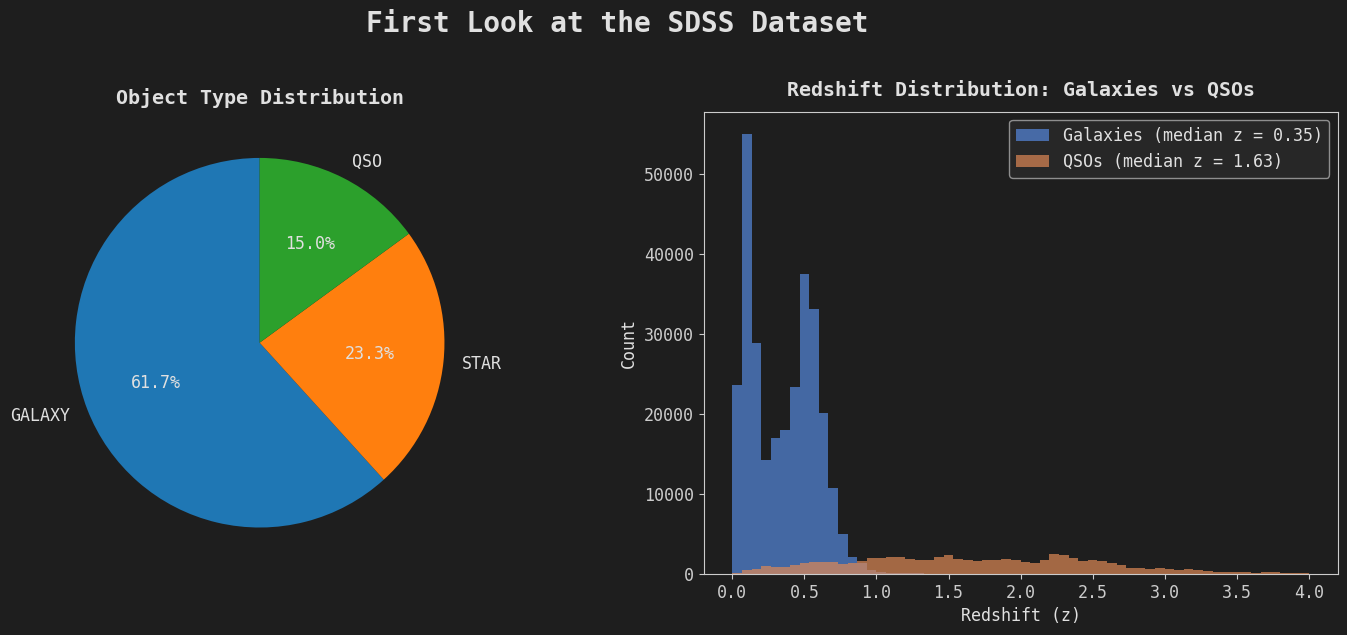

In [16]:
graphs.prelim_plots(df) # Display preliminary plots

<div style="width: 1200px">
Now a few things stand out immediately:

<br>

1. **Galaxies dominate the dataset**: they make up the majority of the sample, confirming that this dataset is well-suited to galaxy evolution studies.

2. **QSOs reach far deeper into the universe than galaxies**: the redshift histograms reveal that quasars extend to much higher redshift values, reflecting their extreme luminosity.

3. Interestingly, there are **2 "spikes" in the redshift histogram** for galaxies: one at about $z=0.1$ and one at about $z=0.5$. This interesting feature will be explained later on.
</div>

---

### Cleaning the Data

---

<div style="width: 1200px">
The next thing that we have to do is clean up the data a bit. Most datasets have at least a few unreliable or not useful entries, so we should try to eliminate most of them.
</div>

**Step 1: Remove unreliable redshift measurements**

<div style="width: 1200px">

Any object with a non-zero `zWarning` has a potentially unreliable redshift. Since redshift is central to almost every downstream analysis, we remove these entries:

</div>

In [ ]:
n_before = len(df) # Count the number of objects before filtering
df = df[df["zWarning"] == 0] # Keep only objects with zWarning equal to 0, which indicates reliable redshift measurements
n_after = len(df) # Count the number of objects after filtering

# Print the number of objects removed due to non-zero zWarning and the number of objects retained in the dataset after filtering
print(f"Removed {n_before - n_after:,} objects with non-zero zWarning")
print(f"Retained {n_after:,} objects ({100 * n_after / n_before:.1f}% of original)")

**Step 2: Remove invalid photometry**

<div style="width: 1200px">

Occasionally, one or more of the five photometric bands (`u`, `g`, `r`, `i`, `z`) contains a missing, zero, or negative value, which is physically impossible for a brightness measurement. We'll keep only objects with valid readings across all bands:

</div>

In [ ]:
photometry_bands = ["u", "g", "r", "i", "z"] # Define the list of photometric bands to check for valid measurements
n_before = len(df) # Count the number of objects before filtering
for band in photometry_bands: # Loop through each photometric band and filter out objects with non-positive values in that band
    df = df[df[band] > 0]
n_after = len(df) # Count the number of objects after filtering

# Print the number of objects removed due to invalid photometry and the number of objects retained in the dataset after filtering
print(f"Removed {n_before - n_after:,} objects with invalid photometry") 
print(f"Retained {n_after:,} objects")

**Step 3: Split the data into class-based subsets**

For the later sections, it will be useful to have three separate DataFrames, one for each object class. This makes targeted analysis much easier.

In [ ]:
# Separate the dataset into subsets based on the "class" column, which indicates whether an object is a galaxy, star, or quasar
galaxies = df[df["class"] == "GALAXY"].copy()
stars = df[df["class"] == "STAR"].copy()
qsos = df[df["class"] == "QSO"].copy()

# Print the number of objects in each class to understand the distribution of object types in the dataset
print(f"Galaxies: {len(galaxies):,}")
print(f"Stars: {len(stars):,}")
print(f"Quasars: {len(qsos):,}")

**Step 4: Remove galaxies with missing structural measurements**

<div style="width: 1200px">

Some galaxies are missing valid values for `petroRad_r` or `fracDeV_r`, which are size and morphology metrics that we will rely on heavily in later chapters. We'll keep only galaxies with positive, physically meaningful values for both:

</div>

In [ ]:
n_before = len(galaxies) # Count the number of galaxies before filtering
galaxies = galaxies[galaxies["petroRad_r"] > 0] # Keep only galaxies with valid structural measurements
n_after = len(galaxies) # Count the number of galaxies after filtering
print(f"Removed {n_before - n_after:,} galaxies with invalid structural measurements") # Print the number of galaxies removed due to invalid measurements
print(f"Final galaxy sample: {n_after:,} objects") # Print the final number of galaxies in the sample after filtering

**Step 5: Remove not useful attributes**

<div style="width: 1200px">

Since stars and quasars appear point-like, they don't have any useful values for `petroRad_r`, `petroR50_r`, `petro_R90_r`, `petroMag_r`, `expAB_r` or `deVAB_r`, so we may as well get rid of those columns for the `stars` and `qsos` DataFrames:

</div>

In [ ]:
# Drop unnecessary columns to save memory and focus on relevant features
stars = stars.drop(columns=["petroRad_r", "petroR50_r", "petroR90_r", "petroMag_r", "expAB_r", "deVAB_r"])
qsos = qsos.drop(columns=["petroRad_r", "petroR50_r", "petroR90_r", "petroMag_r", "expAB_r", "deVAB_r"])

In [ ]:
stars.head(3) # Display the first few rows of the stars subset to check the remaining columns and values

In [ ]:
qsos.head(3) # Display the first few rows of the quasars subset to check the remaining columns and values

---

### Mapping the Sky

---

<div style="width: 1200px">

We'll close this introductory notebook with an interactive sky map.

Here, each point is one celestial object, plotted at its precise sky position. Galaxies, stars, and quasars are coloured separately. You can zoom and pan to explore individual regions of the sky :)

</div>

In [ ]:
graphs.sky_map(df) # Display a sky map of the objects in the dataset, colored by their class (galaxy, star, quasar)

<div style="width: 1200px">

While this map is just a little fun interative, it actually reveals what the SDSS really recorded. Its survey covers specific bits of the Northern sky, with visible gaps where the telescope has not yet observed (or where the galactic plane obscures the view).

</div>


---

### What's Next?

---

<div style="width: 1200px">

We now have a clean, well-understood dataset and a clear picture of what we're working with. In the next sections, we will progressively zoom in on the properties of galaxies, examining:

* **Colour bimodality**: why galaxies split into two distinct populations
* **Size, shape, and morphology**: how structure relates to evolutionary state
* **Distances and luminosities**: looking at the brightness and distance of galaxies
* **Machine learning models**: predicting galaxy class, redshift, and lifecycle position

Let's begin!!

</div>